# Imports

- **Replace Null Values in Age column**

### 4- Handle Outliers

- **Check for Outliers**

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.drop(['PassengerId','Name', 'Ticket'], axis = 1, inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## Chk datatype

In [4]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [5]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [6]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [7]:
chk_types_table(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,str,float64,int64,int64,float64,str,str
Num_Unique,2,3,2,88,7,7,248,147,3


In [8]:
cols = ['Pclass',
        'Survived',
        'Sex',
        'SibSp',
        'Parch',
        'Embarked']
df[cols] = df[cols].astype('category')


In [9]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,str,category
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [10]:
df.shape[0]

891

In [11]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio %,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [12]:
median_1 = df['Age'].median()
df['Age'].fillna(median_1, inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [13]:
df.dropna(subset=['Embarked'], inplace= True)
df = df.drop("Cabin", axis=1)

In [14]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Null,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,19.910011,0.0,0.0,0.0,0.0


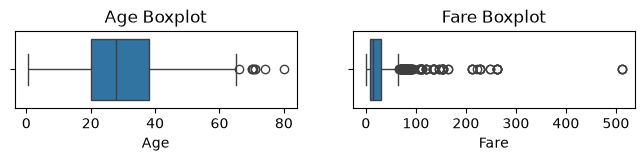

In [15]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")


# the begining of outliers


In [16]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # print(IQR)
    Lower_Fence = Q1 - 1.5*IQR # you can multiply with 1.5 or 3 depending on how strict you want to be with outlier detection. 1.5 is a common choice for mild outliers, while 3 is used for extreme outliers.
    Upper_Fence = Q3 + 1.5*IQR
    print(Lower_Fence)
    print(Upper_Fence)
    Lower_Outliers = df[df[col]< Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
    df[col].replace(Upper_Outliers, Upper_Fence, inplace= True)

-7.0
65.0
-26.7605
65.6563


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,712.0,29.642093,14.492933,0.42,20.0000,28.0000,38.0,80.0000
Fare,889.0,32.096681,49.697504,0.00,7.8958,14.4542,31.0,512.3292


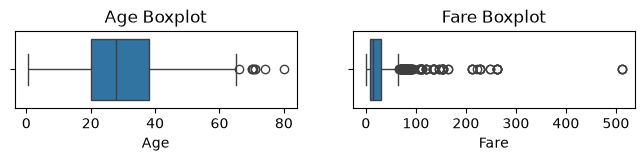

In [18]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [19]:
def replace_outliers(df):
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        # print(IQR)
        Lower_Fence = Q1 - 1.5*IQR # you can multiply with 1.5 or 3 depending on how strict you want to be with outlier detection. 1.5 is a common choice for mild outliers, while 3 is used for extreme outliers.
        Upper_Fence = Q3 + 1.5*IQR
        
        df[col] = df[col].clip(lower=Lower_Fence, upper=Upper_Fence)
    
    return df    

In [20]:
df = replace_outliers(df)

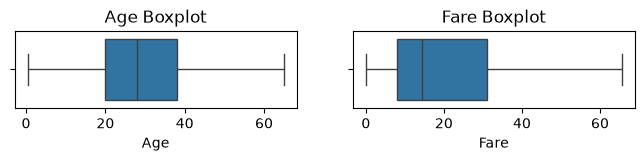

In [21]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [22]:
def handle_outliers(df, algo = "iqr", treatment = "median", multiplier = 1.5, z_thresh = 3):
    num_cols = df.select_dtypes('number').columns
    for col in num_cols:
        if algo == "iqr":
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            Lower_Fence = Q1 - multiplier*IQR
            Upper_Fence = Q3 + multiplier*IQR
            
            if treatment == "median":
                median_value = df[col].median()
                df[col] = np.where(df[col] < Lower_Fence, median_value, df[col])
                df[col] = np.where(df[col] > Upper_Fence, median_value, df[col])
            elif treatment == "mean":
                mean_value = df[col].mean()
                df[col] = np.where(df[col] < Lower_Fence, mean_value, df[col])
                df[col] = np.where(df[col] > Upper_Fence, mean_value, df[col])
            elif treatment == "clip":
                df[col] = np.clip(df[col], Lower_Fence, Upper_Fence)
    
    return df

In [23]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 889, dtype: bool

In [24]:
df.duplicated().sum()

np.int64(120)

In [25]:
df.drop_duplicates(inplace= True) # to remove duplicate rows from the DataFrame.

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
def remove_duplicates(df, subset=None, keep='first'):
    
    return (df.drop_duplicates(subset=subset, keep=keep).reset_index(drop=True))

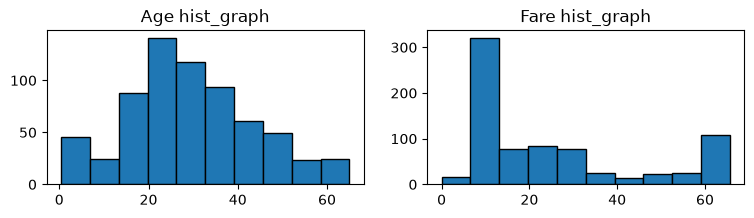

In [28]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.show()


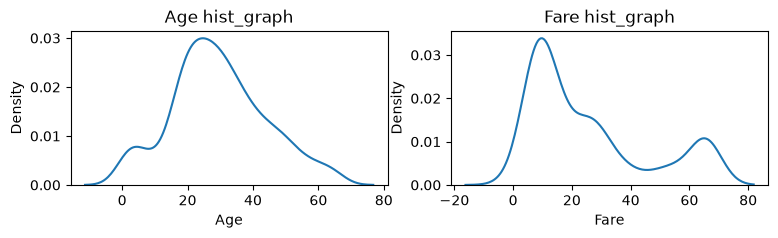

In [29]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.show()

In [30]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

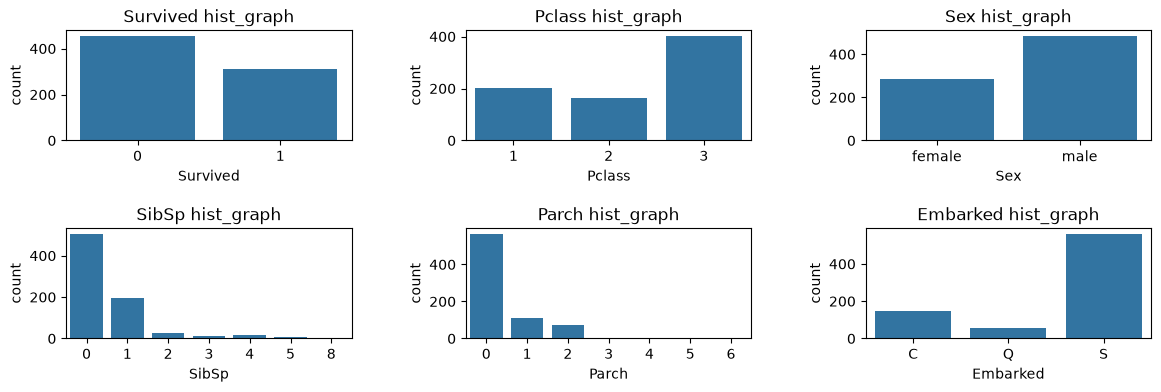

In [31]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} hist_graph")
plt.subplots_adjust(hspace=0.8, wspace=0.4)  
plt.show()

In [32]:
unique = df['Pclass'].value_counts()
count = unique.values
print(unique)
print(count)

Pclass
3    403
1    203
2    163
Name: count, dtype: int64
[403 203 163]


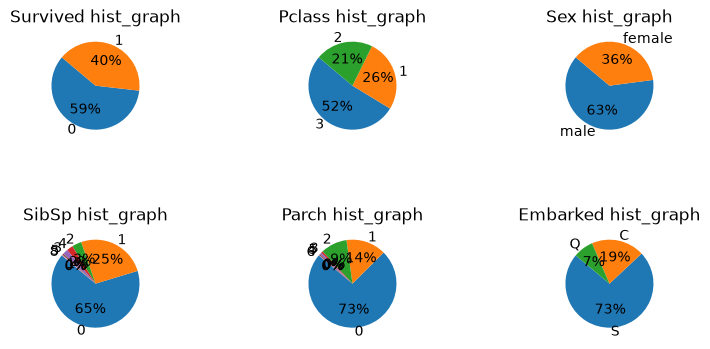

In [33]:
cat_cols = df.select_dtypes("category").columns

plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories =  unique.index
    plt.pie(count, labels=categories, startangle=140, autopct= '%1.1d%%')
    plt.subplots_adjust(hspace=0.8, wspace=0.4)  
    plt.title(f"{col} hist_graph")  

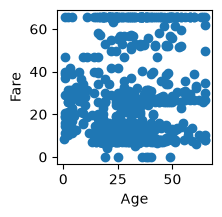

In [34]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

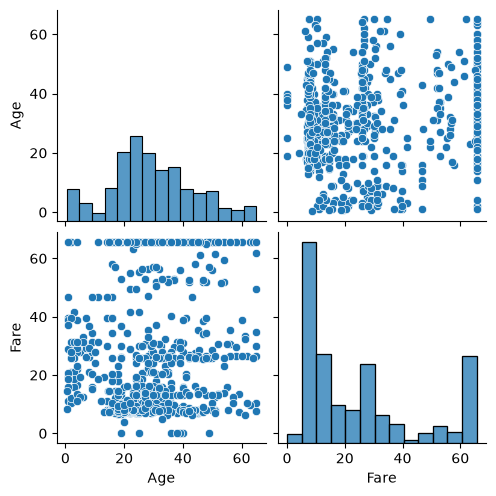

In [35]:
sns.pairplot(df)

In [36]:
corr =df.corr(numeric_only=True)
corr

,Age,Fare
Age,1.000000,0.152138
Fare,0.152138,1.000000


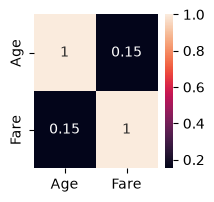

In [37]:
corr  =  df[num_cols].corr()

plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True)
plt.show()

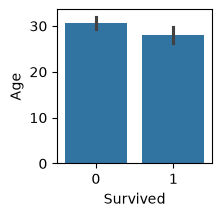

In [38]:
plt.figure(figsize=(2,2))
sns.barplot(x = "Survived", y="Age",data = df)
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

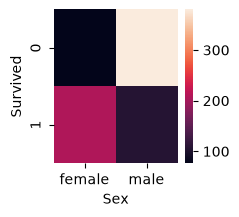

In [39]:
plt.figure(figsize=(2,2))
agg = df.pivot_table(index="Survived", columns="Sex",values="Age", aggfunc=len)
sns.heatmap(agg)
